🔹 Initializing EfficientNet...
✅ EfficientNet ready.
🔹 Loading ViT...
✅ ViT weights loaded from torchvision pretrained.
✅ ViT ready.
Ensemble Accuracy: 0.6008


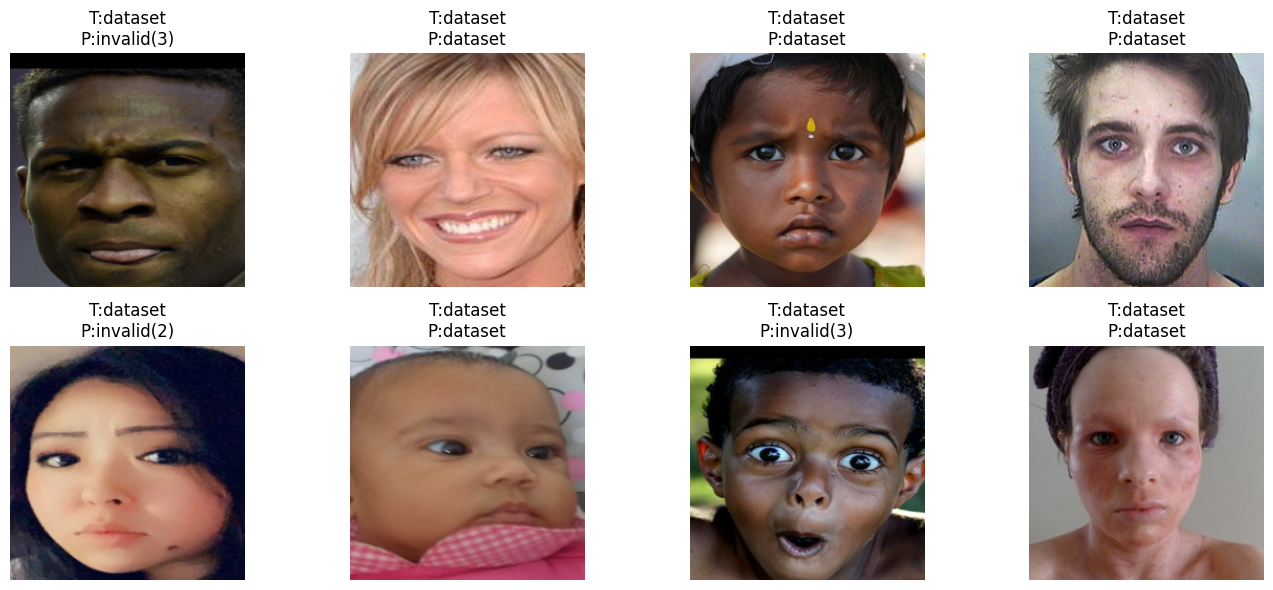

In [15]:

from matplotlib import pyplot as plt
from evaluation.EmotionVisionTransformer import build_emotion_vit_model
import torchvision
import timm
from torch.utils.data import random_split, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.models as tv_models

def adapt_vit_torchvision(model, num_classes=6):
    # torchvision ViT models
    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, num_classes)
    return model

def adapt_efficientnet_torchvision(model, num_classes=6):
    # torchvision EfficientNet (e.g., efficientnet_b0)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

def adapt_timm(model, num_classes=6):
    # for timm models that expose reset_classifier
    if hasattr(model, "reset_classifier"):
        model.reset_classifier(num_classes)
        return model
    # common fallback names
    for name in ["head", "fc", "classifier"]:
        if hasattr(model, name):
            mod = getattr(model, name)
            if isinstance(mod, nn.Linear):
                in_features = mod.in_features
                setattr(model, name, nn.Linear(in_features, num_classes))
                return model
            if isinstance(mod, nn.Sequential) and len(mod) and isinstance(mod[-1], nn.Linear):
                in_features = mod[-1].in_features
                mod[-1] = nn.Linear(in_features, num_classes)
                setattr(model, name, mod)
                return model
    raise RuntimeError("Could not adapt classifier head; unknown model structure.")

@torch.no_grad()
def evaluate_ensemble(models, loader, device="cuda"):
    for m in models:
        m.eval()
        m.to(device)

    correct, total = 0, 0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = []
        for m in models:
            logits = m(images)
            # All models must output [B, 6]
            outputs.append(torch.softmax(logits, dim=1))

        # Average probabilities
        avg_output = torch.stack(outputs, dim=0).mean(dim=0)

        preds = avg_output.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.append(preds.detach().cpu())
        all_labels.append(labels.detach().cpu())

    acc = correct / total if total else 0.0
    return acc, torch.cat(all_preds), torch.cat(all_labels)


# -----------------------------
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ----------------كنولوجيا_الخلايا_التحويلية-------------
# Hyperparameters
batch_size = 32
num_classes = 6  # change according to your dataset
data_path = "/home/julian/.cache/kagglehub/datasets/sujaykapadnis/emotion-recognition-dataset/versions/1"  # path to your dataset folder

# -----------------------------
# Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# -----------------------------
# Dataset & Split
dataset = ImageFolder(root=data_path, transform=transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# -----------------------------
# Python
def EmotionEfficientNet(num_classes: int):
    # Create base model without pretrained weights (we'll load our own if available)
    efficient_model = tv_models.efficientnet_b0(weights=None)
    # efficientnet_b0 has classifier = [Dropout(p=0.2, inplace=True), Linear(in_features, 1000)]
    in_features = efficient_model.classifier[1].in_features
    efficient_model.classifier[1] = nn.Linear(in_features, num_classes)
    return efficient_model

# Example usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 6
print("🔹 Initializing EfficientNet...")
efficient_model = EmotionEfficientNet(num_classes).to(device)
# If you want to load weights using your helper, adapt it to accept a torchvision model
# or ensure it does not instantiate a different EfficientNet class internally.
print("✅ EfficientNet ready.")

print("🔹 Loading ViT...")
# ViT now uses the defined class and builder
vit_model = build_emotion_vit_model(num_classes=num_classes, use_pretrained=False).to(device)
# Try to use torchvision's default pretrained ViT and save its state_dict locally,
# then load into our timm-based head (handling potential key prefixes).
try:
    tv_vit = torchvision.models.vit_b_16(weights=torchvision.models.ViT_B_16_Weights.DEFAULT)
    torch.save(tv_vit.state_dict(), "vit_b_16_weights.pth")
    state_dict = torch.load("vit_b_16_weights.pth", map_location="cuda")
    # Normalize key names: strip possible 'vit.' prefix from external checkpoints
    new_state_dict = {k.replace("vit.", ""): v for k, v in state_dict.items()}
    vit_model.load_state_dict(new_state_dict, strict=False)
    print("✅ ViT weights loaded from torchvision pretrained.")
except Exception as e:
    print(f"⚠️ Failed to load torchvision ViT pretrained weights: {e}")
    print("Proceeding with randomly initialized ViT weights (strict=False).")

vit_model.to(device).eval()
print("✅ ViT ready.")

# -----------------------------
# Ensemble Prediction (Simple Average)
def evaluate_ensemble(models, loader):
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = [model(images) for model in models]
            outputs = [torch.softmax(o, dim=1) for o in outputs]

            # Average predictions
            avg_output = sum(outputs) / len(outputs)
            _, preds = torch.max(avg_output, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.append(preds.detach().cpu())
            all_labels.append(labels.detach().cpu())

    acc = correct / total if total else 0.0
    return acc, torch.cat(all_preds), torch.cat(all_labels)

# -----------------------------
# Run Ensemble
models = [vit_model, efficient_model]
acc, preds, labels = evaluate_ensemble(models, val_loader)
print(f"Ensemble Accuracy: {acc:.4f}")

# -----------------------------
# Plot some predictions
def plot_predictions(images, labels, preds, class_names, n=8):

    # Ensure class_names length is the source of truth for classes
    num_classes = len(class_names)

    # Normalize preds to class indices: handle logits, probabilities, tensors, lists
    if isinstance(preds, torch.Tensor):
        if preds.ndim == 2 and preds.size(1) == num_classes:
            pred_indices = preds.argmax(dim=1).detach().cpu().tolist()
        else:
            pred_indices = preds.detach().cpu().tolist()
    elif isinstance(preds, np.ndarray):
        if preds.ndim == 2 and preds.shape[1] == num_classes:
            pred_indices = preds.argmax(axis=1).tolist()
        else:
            pred_indices = preds.tolist()
    else:
        pred_indices = list(preds)

    # Convert labels to plain Python ints (support tensors/ndarrays)
    if isinstance(labels, torch.Tensor):
        label_indices = labels.detach().cpu().tolist()
    elif isinstance(labels, np.ndarray):
        label_indices = labels.tolist()
    else:
        label_indices = list(labels)

    # Safety: make lengths consistent
    count = min(n, len(images), len(label_indices), len(pred_indices))

    # Helper to safely fetch class name
    def safe_name(idx):
        try:
            idx_int = int(idx)
            if 0 <= idx_int < num_classes:
                return class_names[idx_int]
            return f"invalid({idx_int})"
        except Exception:
            return "invalid(?)"

    plt.figure(figsize=(14, 6))
    for i in range(count):
        ax = plt.subplot(2, (count + 1)//2, i + 1)
        img = images[i]
        if isinstance(img, torch.Tensor):
            img = img.permute(1, 2, 0).detach().cpu().numpy()
        # Denormalize if you normalized by mean=0.5, std=0.5; adjust if different
        img = img * 0.5 + 0.5
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        t_name = safe_name(label_indices[i])
        p_name = safe_name(pred_indices[i])
        ax.set_title(f"T:{t_name}\nP:{p_name}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Get some images from validation set
images, labels_batch = next(iter(val_loader))
plot_predictions(images, labels_batch, preds[:len(labels_batch)], dataset.classes)
